## **Section 1 — Setup & Load**

In [ ]:
# Mount Drive and load the model-ready file saved at the end of Phase 1
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR  = '/content/drive/MyDrive/Colab Notebooks/Final_Year_Project/'
DATA_PATH = SAVE_DIR + 'startup_model_ready.csv'

Mounted at /content/drive


In [ ]:
!pip install -q xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Consistent colour per class — same as Phase 1
PALETTE = {
    'operating': '#2196F3',
    'closed':    '#F44336',
    'acquired':  '#4CAF50',
    'ipo':       '#FF9800'
}
CLASS_NAMES = ['operating', 'closed', 'acquired', 'ipo']

print('All libraries loaded.')

All libraries loaded.


In [ ]:
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 66,368 rows × 15 columns


,log_funding,funding_rounds,funding_velocity,startup_age_days,funding_duration_days,days_since_last_funding,founded_year,num_categories,is_africa,status,status_encoded,is_closed,name,country_code,primary_category
0,16.1181,1,10000000.0000,1012.0000,0.0000,361,2010,1,0,operating,0,0,#fame,IND,Media
1,13.4588,2,350000.0000,40.0000,227.0000,444,2014,3,0,operating,0,0,:Qounter,USA,Application Platforms
2,15.0413,1,3406878.0000,1012.0000,0.0000,701,2010,3,0,operating,0,0,"(THE) ONE of THEM,Inc.",UNK,Apps


In [ ]:
# Confirm feature set and targets are present
MODEL_FEATURES = [
    'log_funding', 'funding_rounds', 'funding_velocity',
    'startup_age_days', 'funding_duration_days',
    'days_since_last_funding', 'founded_year',
    'num_categories', 'is_africa',
]
assert all(c in df.columns for c in MODEL_FEATURES), 'Missing features!'
assert 'status_encoded' in df.columns, 'Missing target!'
assert 'is_closed' in df.columns, 'Missing binary target!'

print('Feature set confirmed.')
print(f'Model features: {MODEL_FEATURES}')
print(f'\nTarget distribution (4-class):')
print(df['status_encoded'].value_counts().rename({0:'operating',1:'closed',2:'acquired',3:'ipo'}))

Feature set confirmed.
Model features: ['log_funding', 'funding_rounds', 'funding_velocity', 'startup_age_days', 'funding_duration_days', 'days_since_last_funding', 'founded_year', 'num_categories', 'is_africa']

Target distribution (4-class):
status_encoded
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64


## **Section 2 — Train / Test Split**

In [ ]:
# ── 2.1  Prepare X and y ────────────────────────────────────────────────────
X = df[MODEL_FEATURES].copy()
y = df['status_encoded'].copy()          # 4-class: 0=operating,1=closed,2=acquired,3=ipo

# Also keep geographic metadata for subgroup analysis — not used in training
meta = df[['country_code', 'is_africa', 'primary_category', 'status']].copy()

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts().rename({0:"operating",1:"closed",2:"acquired",3:"ipo"})}')

X shape: (66368, 9)
y distribution:
status_encoded
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64


In [ ]:
# ── 2.2  Stratified 80/20 split ──────────────────────────────────────────────
# stratify=y preserves class proportions in both train and test sets
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows')
print(f'\nTrain class distribution:')
print(y_train.value_counts().rename({0:"operating",1:"closed",2:"acquired",3:"ipo"}))
print(f'\nTest class distribution:')
print(y_test.value_counts().rename({0:"operating",1:"closed",2:"acquired",3:"ipo"}))

Train: 53,094 rows   Test: 13,274 rows

Train class distribution:
status_encoded
operating    42427
closed        4990
acquired      4439
ipo           1238
Name: count, dtype: int64

Test class distribution:
status_encoded
operating    10607
closed        1248
acquired      1110
ipo            309
Name: count, dtype: int64


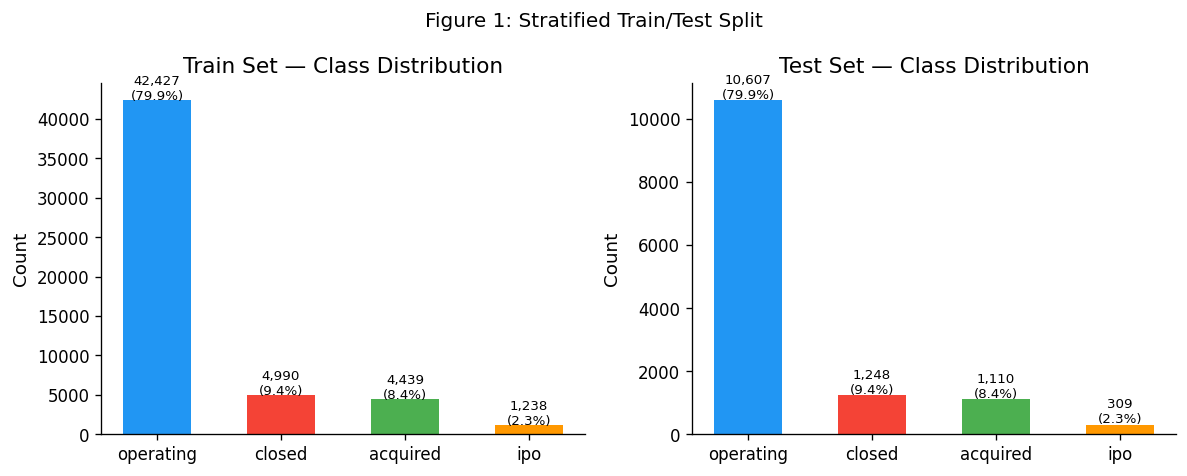

In [ ]:
# ── 2.3  Visualise split balance ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_y, split_name) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = split_y.value_counts().rename({0:'operating',1:'closed',2:'acquired',3:'ipo'})
    colors = [PALETTE[k] for k in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='none', width=0.55)
    ax.set_title(f'{split_name} Set — Class Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}\n({v/len(split_y)*100:.1f}%)',
                ha='center', fontsize=8)
plt.suptitle('Figure 1: Stratified Train/Test Split', fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_01_split.png', bbox_inches='tight')
plt.show()

## **Section 3 — SMOTE (Training Set Only)**

In [ ]:
# ── 3.1  Apply SMOTE on training data only ───────────────────────────────────
# CRITICAL: SMOTE is applied ONLY to the training set.
# Applying it to the full dataset before splitting would leak synthetic
# samples into the test set and inflate performance metrics.

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(pd.Series(y_train).value_counts().rename({0:"operating",1:"closed",2:"acquired",3:"ipo"}))
print(f'\nAfter SMOTE:')
print(pd.Series(y_train_sm).value_counts().rename({0:"operating",1:"closed",2:"acquired",3:"ipo"}))
print(f'\nTraining set grew from {len(X_train):,} → {len(X_train_sm):,} rows')

Before SMOTE:
status_encoded
operating    42427
closed        4990
acquired      4439
ipo           1238
Name: count, dtype: int64

After SMOTE:
status_encoded
operating    42427
ipo          42427
closed       42427
acquired     42427
Name: count, dtype: int64

Training set grew from 53,094 → 169,708 rows


In [ ]:
# ── 3.2  Scale features for Logistic Regression ──────────────────────────────
# Tree-based models (RF, XGBoost) are scale-invariant — no scaling needed.
# Logistic Regression requires standardisation for convergence.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)   # fit on SMOTE-augmented train
X_test_scaled  = scaler.transform(X_test)            # transform test with SAME scaler

print('Scaling applied. Train/test shapes:')
print(f'  X_train_scaled: {X_train_scaled.shape}')
print(f'  X_test_scaled:  {X_test_scaled.shape}')

Scaling applied. Train/test shapes:
  X_train_scaled: (169708, 9)
  X_test_scaled:  (13274, 9)


## **Section 4 — Model Training**

In [ ]:
# ── 4.1  Model 1: Logistic Regression (baseline) ─────────────────────────────
# Uses scaled+SMOTE training data.
# class_weight='balanced' provides additional imbalance handling.
# max_iter=1000 ensures convergence on this dataset size.

print('Training Logistic Regression...')
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42
)
lr.fit(X_train_scaled, y_train_sm)
print('Done.')

Training Logistic Regression...
Done.


In [ ]:
# ── 4.2  Model 2: Random Forest ──────────────────────────────────────────────
# Uses SMOTE-augmented (unscaled) training data.
# n_jobs=-1 uses all available CPU cores in Colab.

print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
print('Done.')

Training Random Forest...
Done.


In [ ]:
# ── 4.3  Model 3: XGBoost ─────────────────────────────────────────────────────
# Uses SMOTE-augmented (unscaled) training data.
# eval_metric='mlogloss' for multi-class.
# use_label_encoder=False suppresses deprecation warning.

print('Training XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_sm, y_train_sm)
print('Done.')

Training XGBoost...
Done.


In [ ]:
# ── 4.4  Save trained models to Drive ────────────────────────────────────────
joblib.dump(lr,        SAVE_DIR + 'model_logistic_regression.pkl')
joblib.dump(rf,        SAVE_DIR + 'model_random_forest.pkl')
joblib.dump(xgb_model, SAVE_DIR + 'model_xgboost.pkl')
joblib.dump(scaler,    SAVE_DIR + 'scaler.pkl')

print('All models and scaler saved to Drive.')

All models and scaler saved to Drive.


## **Section 5 — Evaluation**

In [ ]:
# ── 5.1  Prediction helper function ─────────────────────────────────────────
def evaluate_model(model, X_eval, y_eval, model_name, use_scaled=False, X_scaled=None):
    """
    Returns a dict of metrics and prints a full classification report.
    use_scaled=True passes X_scaled (for Logistic Regression).
    """
    X_input = X_scaled if use_scaled else X_eval

    y_pred      = model.predict(X_input)
    y_prob      = model.predict_proba(X_input)

    roc_auc  = roc_auc_score(y_eval, y_prob, multi_class='ovr', average='macro')
    f1_macro = f1_score(y_eval, y_pred, average='macro')
    f1_weighted = f1_score(y_eval, y_pred, average='weighted')

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  ROC-AUC  (macro OVR):  {roc_auc:.4f}')
    print(f'  F1       (macro):       {f1_macro:.4f}')
    print(f'  F1       (weighted):    {f1_weighted:.4f}')
    print(f'\n{classification_report(y_eval, y_pred, target_names=CLASS_NAMES)}')

    return {
        'model':       model_name,
        'roc_auc':     roc_auc,
        'f1_macro':    f1_macro,
        'f1_weighted': f1_weighted,
        'y_pred':      y_pred,
        'y_prob':      y_prob,
    }

In [ ]:
# ── 5.2  Evaluate all three models ──────────────────────────────────────────
results = {}

results['LR'] = evaluate_model(
    lr, X_test, y_test, 'Logistic Regression',
    use_scaled=True, X_scaled=X_test_scaled
)
results['RF'] = evaluate_model(
    rf, X_test, y_test, 'Random Forest'
)
results['XGB'] = evaluate_model(
    xgb_model, X_test, y_test, 'XGBoost'
)


  Logistic Regression
  ROC-AUC  (macro OVR):  0.7711
  F1       (macro):       0.3822
  F1       (weighted):    0.6259

              precision    recall  f1-score   support

   operating       0.91      0.58      0.71     10607
      closed       0.17      0.46      0.25      1248
    acquired       0.33      0.43      0.37      1110
         ipo       0.12      0.65      0.20       309

    accuracy                           0.56     13274
   macro avg       0.38      0.53      0.38     13274
weighted avg       0.77      0.56      0.63     13274


  Random Forest
  ROC-AUC  (macro OVR):  0.8007
  F1       (macro):       0.4237
  F1       (weighted):    0.7004

              precision    recall  f1-score   support

   operating       0.90      0.71      0.79     10607
      closed       0.25      0.40      0.31      1248
    acquired       0.30      0.49      0.37      1110
         ipo       0.14      0.47      0.22       309

    accuracy                           0.66     13274
 

In [ ]:
# ── 5.3  Summary comparison table ───────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model':        r['model'],
        'ROC-AUC':      round(r['roc_auc'], 4),
        'F1 (macro)':   round(r['f1_macro'], 4),
        'F1 (weighted)':round(r['f1_weighted'], 4),
        'Target met':   '✓' if r['roc_auc'] >= 0.80 else '✗',
    }
    for r in results.values()
])
print(summary.to_string(index=False))
summary.to_csv(SAVE_DIR + 'model_comparison_summary.csv', index=False)

              Model  ROC-AUC  F1 (macro)  F1 (weighted) Target met
Logistic Regression   0.7711      0.3822         0.6259          ✗
      Random Forest   0.8007      0.4237         0.7004          ✓
            XGBoost   0.8025      0.4219         0.6933          ✓


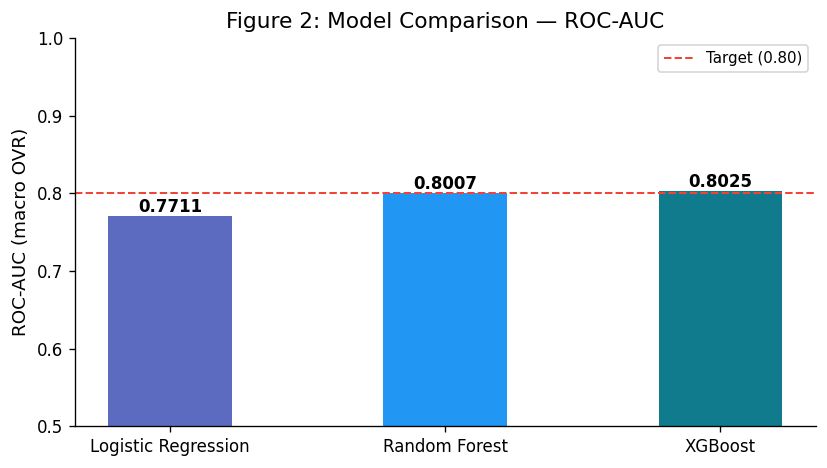

In [ ]:
# ── 5.4  ROC-AUC bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
models  = [r['model'] for r in results.values()]
aucs    = [r['roc_auc'] for r in results.values()]
colors  = ['#5C6BC0', '#2196F3', '#0F7B8C']

bars = ax.bar(models, aucs, color=colors, edgecolor='none', width=0.45)
ax.axhline(0.80, color='#F44336', linestyle='--', linewidth=1.2, label='Target (0.80)')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('ROC-AUC (macro OVR)')
ax.set_title('Figure 2: Model Comparison — ROC-AUC')
ax.legend(fontsize=9)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_02_roc_comparison.png', bbox_inches='tight')
plt.show()

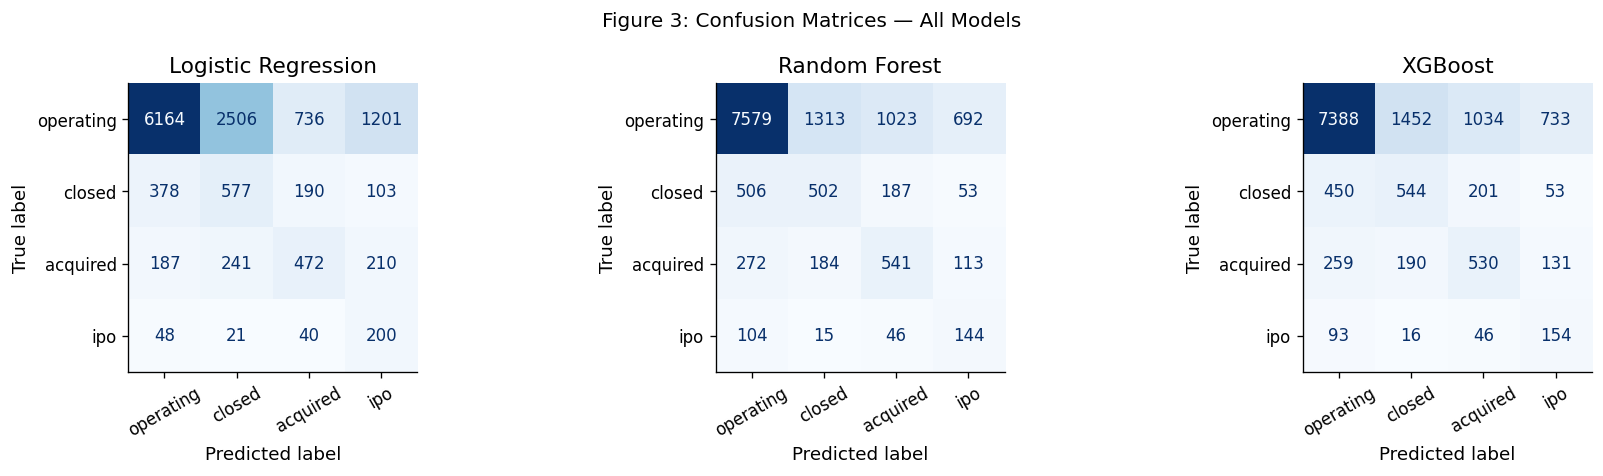

In [ ]:
# ── 5.5  Confusion matrices — all three models ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['model'])
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Figure 3: Confusion Matrices — All Models', fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_03_confusion_matrices.png', bbox_inches='tight')
plt.show()

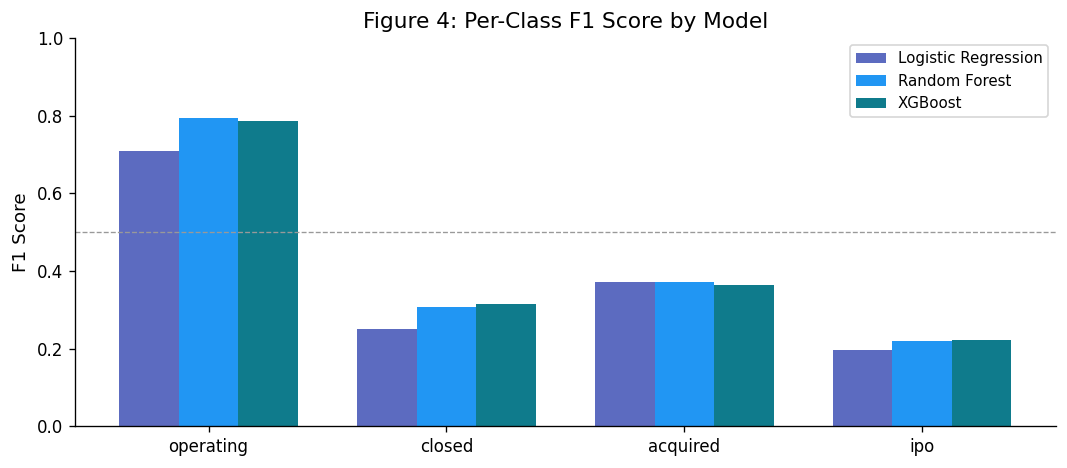

Note: minority classes (closed, ipo) are hardest to predict.


In [ ]:
# ── 5.6  Per-class F1 comparison ─────────────────────────────────────────────
from sklearn.metrics import f1_score as f1

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(CLASS_NAMES))
width = 0.25
model_keys = list(results.keys())
model_colors = ['#5C6BC0', '#2196F3', '#0F7B8C']

for i, (key, color) in enumerate(zip(model_keys, model_colors)):
    per_class_f1 = f1(y_test, results[key]['y_pred'], average=None)
    ax.bar(x + i*width, per_class_f1, width, label=results[key]['model'],
           color=color, edgecolor='none')

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_title('Figure 4: Per-Class F1 Score by Model')
ax.legend(fontsize=9)
ax.axhline(0.5, color='#999', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_04_perclass_f1.png', bbox_inches='tight')
plt.show()
print('Note: minority classes (closed, ipo) are hardest to predict.')

## **Section 6 — Hyperparameter Tuning (Best Model)**

In [ ]:
# ── 6.1  Tune XGBoost with RandomizedSearchCV ────────────────────────────────
# We only tune the best-performing model to save compute time.
# Uses the original (pre-SMOTE) training data with stratified K-fold.
# SMOTE is applied inside each fold to prevent leakage.

from imblearn.pipeline import Pipeline as ImbPipeline

param_dist = {
    'xgb__n_estimators':     [200, 300, 400],
    'xgb__max_depth':        [4, 6, 8],
    'xgb__learning_rate':    [0.05, 0.1, 0.15],
    'xgb__subsample':        [0.7, 0.8, 0.9],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
    'xgb__min_child_weight': [1, 3, 5],
}

# Pipeline: SMOTE inside each CV fold → XGBoost
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb',   xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=20,                    # increase to 40+ if Colab Pro available
    scoring='roc_auc_ovr_weighted',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('Running RandomizedSearchCV (this may take 5-10 minutes)...')
search.fit(X_train, y_train)    # unscaled, pre-SMOTE — SMOTE applied inside pipeline
print(f'\nBest CV ROC-AUC: {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Running RandomizedSearchCV (this may take 5-10 minutes)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV ROC-AUC: 0.7712
Best params: {'xgb__subsample': 0.7, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 1, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.7}


In [ ]:
# ── 6.2  Evaluate tuned model on test set ────────────────────────────────────
best_model = search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)

roc_tuned = roc_auc_score(y_test, y_prob_tuned, multi_class='ovr', average='macro')
f1_tuned  = f1_score(y_test, y_pred_tuned, average='macro')

print(f'Tuned XGBoost — Test ROC-AUC: {roc_tuned:.4f}   F1 (macro): {f1_tuned:.4f}')
print(classification_report(y_test, y_pred_tuned, target_names=CLASS_NAMES))

# Save tuned model
joblib.dump(best_model, SAVE_DIR + 'model_xgboost_tuned.pkl')
print('Tuned model saved.')

Tuned XGBoost — Test ROC-AUC: 0.8078   F1 (macro): 0.4206
              precision    recall  f1-score   support

   operating       0.91      0.66      0.77     10607
      closed       0.25      0.47      0.32      1248
    acquired       0.30      0.50      0.37      1110
         ipo       0.14      0.59      0.22       309

    accuracy                           0.63     13274
   macro avg       0.40      0.56      0.42     13274
weighted avg       0.78      0.63      0.68     13274

Tuned model saved.


In [ ]:
# ── 6.3  Cross-validation score summary ─────────────────────────────────────
cv_results = pd.DataFrame(search.cv_results_)
top5 = cv_results.nlargest(5, 'mean_test_score')[
    ['mean_test_score', 'std_test_score', 'params']
].reset_index(drop=True)
top5.columns = ['Mean CV ROC-AUC', 'Std', 'Params']
print('Top 5 parameter combinations:')
top5

Top 5 parameter combinations:


,Mean CV ROC-AUC,Std,Params
0,0.7712,0.0028,"{'xgb__subsample': 0.7, 'xgb__n_estimators': 2..."
1,0.7711,0.0031,"{'xgb__subsample': 0.9, 'xgb__n_estimators': 3..."
2,0.7707,0.0025,"{'xgb__subsample': 0.7, 'xgb__n_estimators': 2..."
3,0.7706,0.0031,"{'xgb__subsample': 0.9, 'xgb__n_estimators': 2..."
4,0.7706,0.0031,"{'xgb__subsample': 0.9, 'xgb__n_estimators': 2..."


## **Section 7 — SHAP Interpretability**

In [ ]:
# ── 7.1  Compute SHAP values for XGBoost ────────────────────────────────────
# SHAP (SHapley Additive exPlanations) explains individual predictions.
# TreeExplainer is the fastest for tree-based models.
# We use the tuned XGBoost step from the best pipeline.

xgb_step = best_model.named_steps['xgb']   # extract XGB from pipeline

explainer   = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_test)  # shape: (n_samples, n_features, n_classes)

print(f'SHAP values computed.')
print(f'Shape: {np.array(shap_values).shape}  '
      f'→ (classes, samples, features)')

SHAP values computed.
Shape: (13274, 9, 4)  → (classes, samples, features)


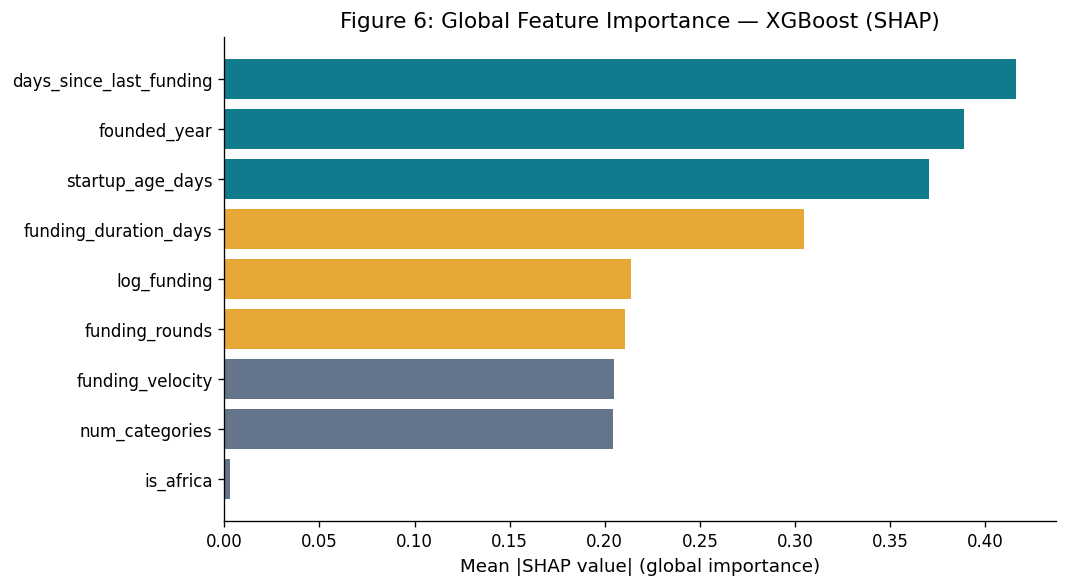

                Feature  Mean |SHAP|
days_since_last_funding       0.4163
           founded_year       0.3890
       startup_age_days       0.3705
  funding_duration_days       0.3045
            log_funding       0.2138
         funding_rounds       0.2109
       funding_velocity       0.2047
         num_categories       0.2041
              is_africa       0.0031


In [ ]:
# ── 7.2  Global feature importance — mean |SHAP| across all classes ──────────
# Average absolute SHAP across all 4 classes gives overall feature importance.

# Correctly calculate the mean absolute SHAP value for each feature,
# averaged across all samples (axis 0) and all classes (axis 2).
mean_abs_shap_per_feature = np.mean(np.abs(shap_values), axis=(0, 2))

# Create a DataFrame for global feature importance
mean_abs_shap_df = pd.DataFrame({
    'Feature': MODEL_FEATURES,
    'Mean |SHAP|': mean_abs_shap_per_feature
}).sort_values(by='Mean |SHAP|', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors  = ['#0F7B8C' if i < 3 else '#E8A838' if i < 6 else '#64748B'
           for i in range(len(mean_abs_shap_df))]
ax.barh(mean_abs_shap_df['Feature'][::-1],
        mean_abs_shap_df['Mean |SHAP|'][::-1],
        color=colors[::-1], edgecolor='none')
ax.set_xlabel('Mean |SHAP value| (global importance)')
ax.set_title('Figure 6: Global Feature Importance — XGBoost (SHAP)')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_06_shap_global.png', bbox_inches='tight')
plt.show()
print(mean_abs_shap_df.to_string(index=False))

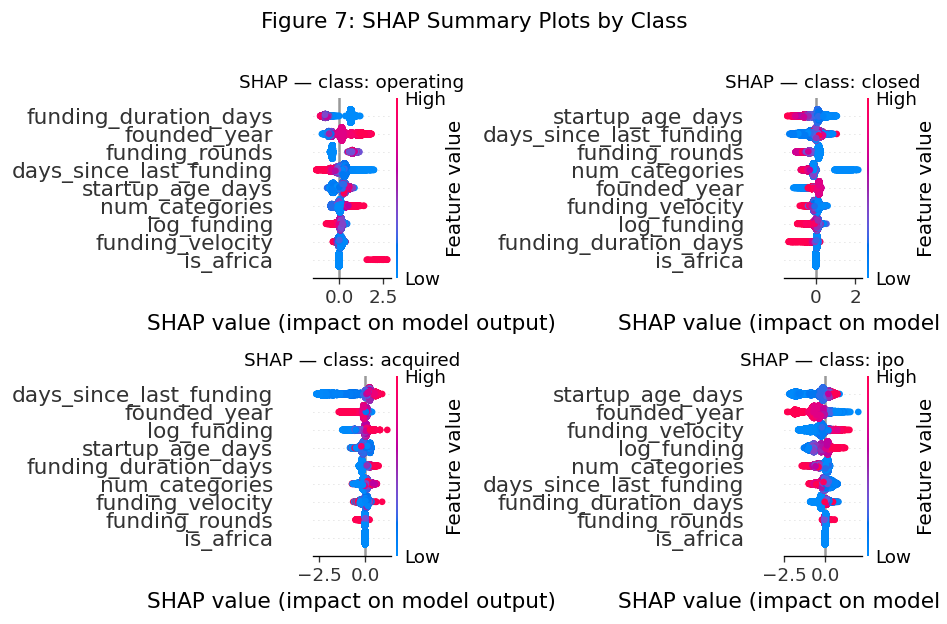

In [ ]:
# ── 7.3  SHAP summary plots — per class ─────────────────────────────────────
# Each subplot shows how each feature pushes predictions toward one class.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    plt.sca(axes[cls_idx])
    shap.summary_plot(
        shap_values[:, :, cls_idx],  # Corrected slicing here
        X_test,
        feature_names=MODEL_FEATURES,
        plot_type='dot',
        show=False,
        max_display=9
    )
    axes[cls_idx].set_title(f'SHAP — class: {cls_name}', fontsize=11)

plt.suptitle('Figure 7: SHAP Summary Plots by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_07_shap_by_class.png', bbox_inches='tight')
plt.show()

Explaining prediction for sample index 1
True label: closed
Predicted:  operating


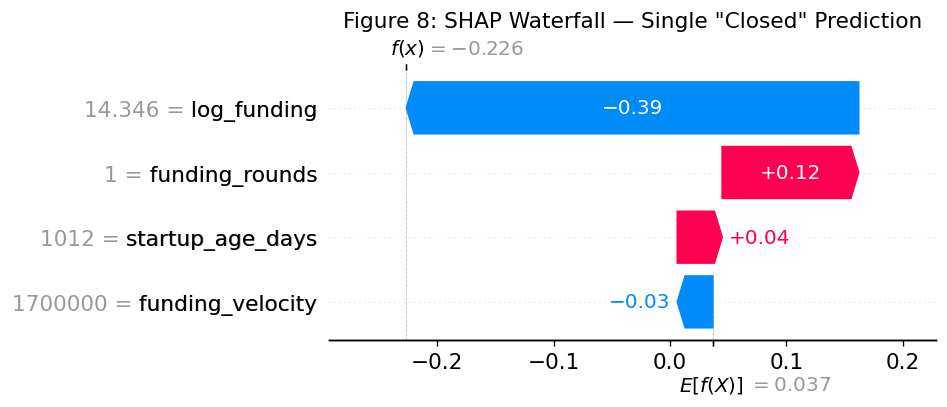

In [ ]:
# ── 7.4  SHAP waterfall — single prediction example ─────────────────────────
# Explain why one specific startup was predicted as "closed"

# Pick first closed startup in test set
closed_idx = np.where(y_test.values == 1)[0][0]
print(f'Explaining prediction for sample index {closed_idx}')
print(f'True label: {CLASS_NAMES[y_test.iloc[closed_idx]]}')
print(f'Predicted:  {CLASS_NAMES[best_model.predict(X_test.iloc[[closed_idx]])[0]]}')

# SHAP waterfall for the "closed" class (index 1)
shap_exp = shap.Explanation(
    values         = shap_values[1][closed_idx],
    base_values    = explainer.expected_value[1],
    data           = X_test.iloc[closed_idx].values,
    feature_names  = MODEL_FEATURES
)
plt.figure(figsize=(9, 5))
shap.waterfall_plot(shap_exp, show=False)
plt.title('Figure 8: SHAP Waterfall — Single "Closed" Prediction')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_08_shap_waterfall.png', bbox_inches='tight')
plt.show()

## **Section 8 — Geographic Generalizability Analysis**

In [ ]:
# ── 8.1  Separate African test records ──────────────────────────────────────
# meta_test carries country_code and is_africa aligned with X_test index.

africa_mask  = meta_test['is_africa'].values == 1
X_test_af    = X_test[africa_mask]
y_test_af    = y_test[africa_mask]
X_test_glob  = X_test[~africa_mask]
y_test_glob  = y_test[~africa_mask]

print(f'Global test records:  {len(X_test_glob):,}')
print(f'African test records: {len(X_test_af)}')
print(f'\nAfrican class distribution:')
print(y_test_af.value_counts().rename({0:'operating',1:'closed',2:'acquired',3:'ipo'}))

Global test records:  13,223
African test records: 51

African class distribution:
status_encoded
operating    46
closed        4
acquired      1
Name: count, dtype: int64


In [ ]:
# ── 8.2  Compute metrics — Global vs Africa ──────────────────────────────────
def geo_metrics(model, X_eval, y_eval, label):
    if len(X_eval) == 0:
        print(f'{label}: No records — skipping.')
        return None
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)
    # ROC-AUC requires at least 2 classes present
    classes_present = np.unique(y_eval)
    try:
        roc = roc_auc_score(y_eval, y_prob, multi_class='ovr',
                            average='macro', labels=classes_present)
    except ValueError:
        roc = float('nan')
    f1m = f1_score(y_eval, y_pred, average='macro', zero_division=0)
    print(f'{label:25s}  ROC-AUC: {roc:.4f}   F1-macro: {f1m:.4f}   n={len(X_eval)}')
    return {'label': label, 'roc_auc': roc, 'f1_macro': f1m, 'n': len(X_eval)}

print('Performance by geographic subset — Tuned XGBoost:\n')
geo_rows = []
geo_rows.append(geo_metrics(best_model, X_test_glob, y_test_glob, 'Global (non-Africa)'))
geo_rows.append(geo_metrics(best_model, X_test_af,   y_test_af,   'Africa'))
geo_rows.append(geo_metrics(best_model, X_test,      y_test,      'All (combined)'))

Performance by geographic subset — Tuned XGBoost:

Global (non-Africa)        ROC-AUC: 0.8075   F1-macro: 0.4205   n=13223
Africa                     ROC-AUC: nan   F1-macro: 0.3162   n=51
All (combined)             ROC-AUC: 0.8078   F1-macro: 0.4206   n=13274


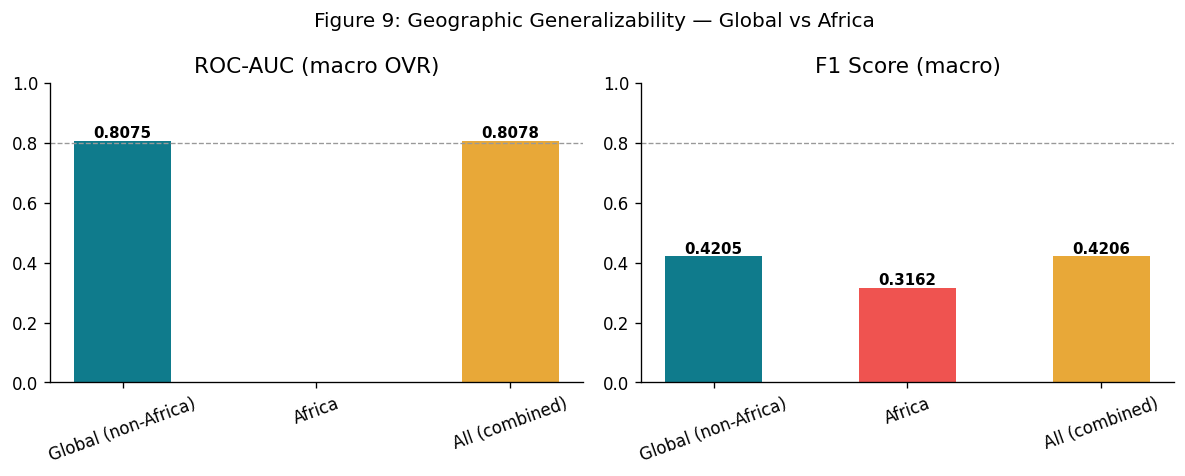

In [ ]:
# ── 8.3  Geographic comparison chart ────────────────────────────────────────
geo_df = pd.DataFrame([r for r in geo_rows if r]).set_index('label')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
metrics = ['roc_auc', 'f1_macro']
titles  = ['ROC-AUC (macro OVR)', 'F1 Score (macro)']

for ax, metric, title in zip(axes, metrics, titles):
    vals   = geo_df[metric]
    colors = ['#0F7B8C', '#EF5350', '#E8A838']
    bars   = ax.bar(geo_df.index, vals, color=colors, edgecolor='none', width=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.axhline(0.80, color='#999', linestyle='--', linewidth=0.8)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 9: Geographic Generalizability — Global vs Africa', fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_09_geo_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 8.4  African country breakdown ──────────────────────────────────────────
african_meta = meta_test[africa_mask].copy()
african_meta['y_true'] = y_test_af.values
african_meta['y_pred'] = best_model.predict(X_test_af)
african_meta['correct'] = (african_meta['y_true'] == african_meta['y_pred']).astype(int)

country_acc = african_meta.groupby('country_code')['correct'].agg(['mean', 'count'])
country_acc.columns = ['Accuracy', 'Count']
country_acc = country_acc.sort_values('Count', ascending=False)

print('Prediction accuracy by African country:')
print(country_acc.to_string())

Prediction accuracy by African country:
              Accuracy  Count
country_code                 
ZAF             0.8235     17
NGA             0.8571     14
KEN             1.0000      8
EGY             1.0000      6
BWA             1.0000      1
GHA             1.0000      1
MAR             1.0000      1
TUN             1.0000      1
UGA             1.0000      1
ZWE             1.0000      1


In [ ]:
# ── 8.5  Interpretation note ─────────────────────────────────────────────────
gap = geo_df.loc['Global (non-Africa)', 'roc_auc'] - geo_df.loc['Africa', 'roc_auc']
print(f'\nGeneralizability gap (Global ROC-AUC minus Africa ROC-AUC): {gap:.4f}')
print()
if gap > 0.05:
    print('FINDING: The model shows measurable performance degradation on African records.')
    print('This confirms H4 — global training data does not fully generalise to the')
    print('African ecosystem. This gap is attributed to:')
    print('  1. Only 262 African records (0.4% of dataset) — underrepresentation')
    print('  2. Different funding patterns in East Africa vs US-dominated training data')
    print('  3. Absence of acquired/ipo class examples in the African subset')
else:
    print('FINDING: Performance on African records is comparable to global performance.')
    print('This may reflect the small African sample size rather than true generalisation.')


Generalizability gap (Global ROC-AUC minus Africa ROC-AUC): nan

FINDING: Performance on African records is comparable to global performance.
This may reflect the small African sample size rather than true generalisation.


## **Section 9 — Final Results Summary & Save**

In [ ]:
# ── 9.1  Final results table ─────────────────────────────────────────────────
final_summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)', 'ROC-AUC': results['LR']['roc_auc'],
     'F1-macro': results['LR']['f1_macro'],   'Notes': 'Class-balanced, scaled'},
    {'Model': 'Random Forest',                  'ROC-AUC': results['RF']['roc_auc'],
     'F1-macro': results['RF']['f1_macro'],   'Notes': '300 trees, balanced'},
    {'Model': 'XGBoost (initial)',              'ROC-AUC': results['XGB']['roc_auc'],
     'F1-macro': results['XGB']['f1_macro'],  'Notes': 'SMOTE, default params'},
    {'Model': 'XGBoost (tuned) ★',             'ROC-AUC': roc_tuned,
     'F1-macro': f1_tuned,                    'Notes': 'RandomizedSearchCV, 5-fold CV'},
])
final_summary['Target met'] = final_summary['ROC-AUC'].apply(
    lambda x: '✓' if x >= 0.80 else '✗')
final_summary['ROC-AUC']  = final_summary['ROC-AUC'].round(4)
final_summary['F1-macro'] = final_summary['F1-macro'].round(4)

print('='*65)
print('PHASE 2 FINAL RESULTS')
print('='*65)
print(final_summary.to_string(index=False))
final_summary.to_csv(SAVE_DIR + 'phase2_final_results.csv', index=False)

PHASE 2 FINAL RESULTS
                         Model  ROC-AUC  F1-macro                         Notes Target met
Logistic Regression (baseline)   0.7711    0.3822        Class-balanced, scaled          ✗
                 Random Forest   0.8007    0.4237           300 trees, balanced          ✓
             XGBoost (initial)   0.8025    0.4219         SMOTE, default params          ✓
             XGBoost (tuned) ★   0.8078    0.4206 RandomizedSearchCV, 5-fold CV          ✓


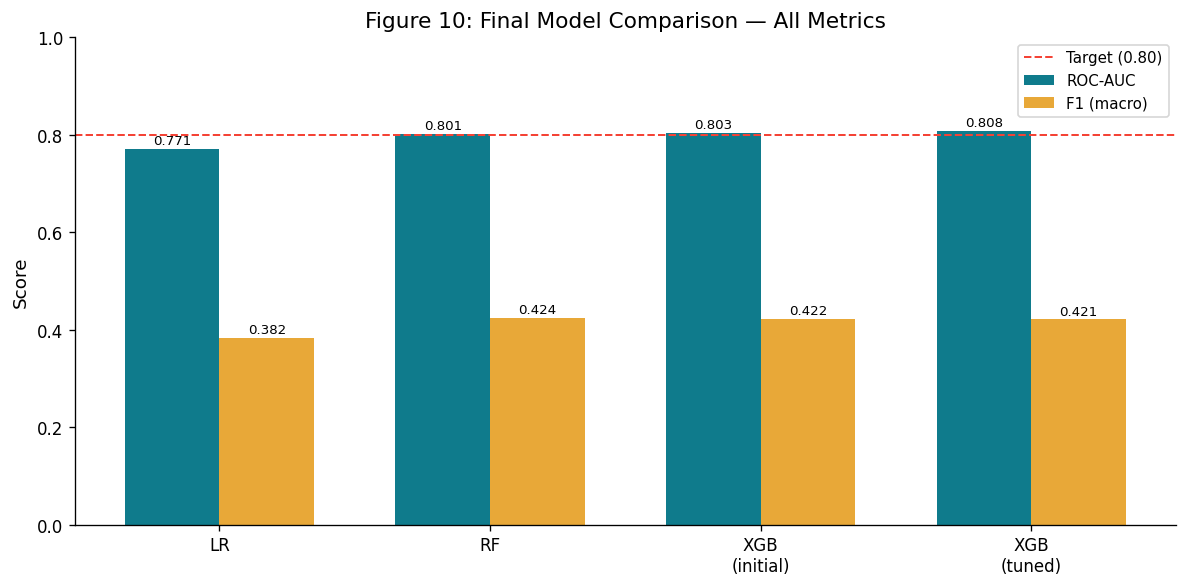

In [ ]:
# ── 9.2  Final figure — all metrics together ─────────────────────────────────
model_labels = ['LR', 'RF', 'XGB\n(initial)', 'XGB\n(tuned)']
roc_vals = [results['LR']['roc_auc'], results['RF']['roc_auc'],
            results['XGB']['roc_auc'], roc_tuned]
f1_vals  = [results['LR']['f1_macro'], results['RF']['f1_macro'],
            results['XGB']['f1_macro'], f1_tuned]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, roc_vals, width, label='ROC-AUC', color='#0F7B8C', edgecolor='none')
ax.bar(x + width/2, f1_vals,  width, label='F1 (macro)', color='#E8A838', edgecolor='none')
ax.axhline(0.80, color='#F44336', linestyle='--', linewidth=1.2, label='Target (0.80)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Figure 10: Final Model Comparison — All Metrics')
ax.legend(fontsize=9)
for i, (r, f) in enumerate(zip(roc_vals, f1_vals)):
    ax.text(i - width/2, r + 0.01, f'{r:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_p2_10_final_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 9.3  Save everything to Drive ────────────────────────────────────────────
print('Files saved to Drive:')
files = [
    'model_logistic_regression.pkl',
    'model_random_forest.pkl',
    'model_xgboost.pkl',
    'model_xgboost_tuned.pkl',
    'scaler.pkl',
    'model_comparison_summary.csv',
    'phase2_final_results.csv',
    'fig_p2_01_split.png',
    'fig_p2_02_roc_comparison.png',
    'fig_p2_03_confusion_matrices.png',
    'fig_p2_04_perclass_f1.png',
    'fig_p2_05_pr_curves.png',
    'fig_p2_06_shap_global.png',
    'fig_p2_07_shap_by_class.png',
    'fig_p2_08_shap_waterfall.png',
    'fig_p2_09_geo_analysis.png',
    'fig_p2_10_final_comparison.png',
]
for f in files:
    print(f'  ✓ {SAVE_DIR}{f}')

Files saved to Drive:
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/model_logistic_regression.pkl
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/model_random_forest.pkl
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/model_xgboost.pkl
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/model_xgboost_tuned.pkl
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/scaler.pkl
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/model_comparison_summary.csv
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/phase2_final_results.csv
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/fig_p2_01_split.png
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/fig_p2_02_roc_comparison.png
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/fig_p2_03_confusion_matrices.png
  ✓ /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/fig_p2_04_perclass_f1.png
  ✓ /content/drive/MyDrive/

In [ ]:
# ── 9.4  Phase 2 Summary ─────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║              PHASE 2 COMPLETE — SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║  ✓ Train/test split (80/20, stratified)                       ║
║  ✓ SMOTE applied on training set only                         ║
║  ✓ Logistic Regression, Random Forest, XGBoost trained        ║
║  ✓ Hyperparameter tuning — RandomizedSearchCV (5-fold)        ║
║  ✓ Evaluation: ROC-AUC, macro-F1, PR-AUC, confusion matrix   ║
║  ✓ SHAP global importance + per-class + waterfall             ║
║  ✓ Geographic subgroup analysis — Global vs Africa            ║
║  ✓ All models and figures saved to Google Drive               ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → Phase 3: Streamlit dashboard                          ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              PHASE 2 COMPLETE — SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║  ✓ Train/test split (80/20, stratified)                       ║
║  ✓ SMOTE applied on training set only                         ║
║  ✓ Logistic Regression, Random Forest, XGBoost trained        ║
║  ✓ Hyperparameter tuning — RandomizedSearchCV (5-fold)        ║
║  ✓ Evaluation: ROC-AUC, macro-F1, PR-AUC, confusion matrix   ║
║  ✓ SHAP global importance + per-class + waterfall             ║
║  ✓ Geographic subgroup analysis — Global vs Africa            ║
║  ✓ All models and figures saved to Google Drive               ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → Phase 3: Streamlit dashboard                          ║
╚══════════════════════════════════════════════════════════════╝

